In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from gsheet_loader import load_sheet

load_dotenv()

# Load a Google Sheet URL from .env
url = os.getenv("GOOGLE_SHEET_URL")
if not url:
    raise ValueError("GOOGLE_SHEET_URL is not set in .env")

data = load_sheet(url)
df = pd.read_csv(data)

In [2]:
df.shape

(452, 51)

In [3]:
df.drop('submittedAt', axis=1, inplace=True)

In [4]:
df['B5_time_with_parents_hours'] = df['B5_time_with_parents_hours'].str.replace('â', '-', regex=False)
df['D1_daily_screen'] = df['D1_daily_screen'].str.replace('â', '-', regex=False)
df['D2_weekend_screen'] = df['D2_weekend_screen'].str.replace('â', '-', regex=False)
df['D5_parents_screen_time'] = df['D5_parents_screen_time'].str.replace('â', '-', regex=False)
df['E1_sleep_duration'] = df['E1_sleep_duration'].str.replace('â', '-', regex=False)

In [5]:
df['A2_gender'].value_counts()

A2_gender
Female    233
Male      219
Name: count, dtype: int64

In [6]:
df.columns

Index(['A1_age_years', 'A2_gender', 'A3_religion', 'A4_marital',
       'B1_residence', 'B2_employed', 'B3_income_tk', 'B4_family_type',
       'B5_time_with_parents_hours', 'B6_relationship_with_family',
       'C1_height_feet', 'C1_height_inches', 'C2_weight_kg',
       'C3_physical_problems', 'D1_daily_screen', 'D2_weekend_screen',
       'D3_device', 'D4_content', 'D5_parents_screen_time', 'D6_ai_daily',
       'D7_ai_impact', 'D8_creativity_decline', 'E1_sleep_duration',
       'E2_after_sleep_feel', 'E3_sleep_medicine', 'E4_addictive_drug',
       'E5_bedtime', 'E6_wake_time', 'F1_academic_satisfaction',
       'F2_screen_impact', 'F3_learning_interest', 'F4_interest_reduced',
       'G1_mood_swings', 'G2_anxious_without_device', 'G3_communication',
       'G4_isolation', 'G5_negative_mental', 'G6_panic_attack',
       'G7_personality', 'H1_mobile_while_eating', 'H2_appetite_change',
       'PHQ9_1', 'PHQ9_2', 'PHQ9_3', 'PHQ9_4', 'PHQ9_5', 'PHQ9_6', 'PHQ9_7',
       'PHQ9_8', 'PH

## **PHQ CAL**

In [7]:
phq_mapping = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3
}

phq_columns = [f"PHQ9_{i}" for i in range(1, 10)]

for c in phq_columns:
    df[c] = df[c].astype("string").str.strip().map(phq_mapping)

print(df[phq_columns].head())


   PHQ9_1  PHQ9_2  PHQ9_3  PHQ9_4  PHQ9_5  PHQ9_6  PHQ9_7  PHQ9_8  PHQ9_9
0       2       1       2       2       1       2       3       0       0
1       2       1       2       0       1       2       3       0       0
2       1       3       2       3       1       3       1       1       2
3       1       3       3       3       2       3       2       3       3
4       3       2       3       3       3       2       0       0       0


In [8]:
df['total_PHQ'] = df[phq_columns].sum(axis=1)

In [9]:
bins = [-1, 4, 9, 14, 19, 27]
labels = [
    'Minimal depressive',
    'Mild depressive',
    'Moderate depressive',
    'Moderately depressive',
    'Severe depressive'
]

df['PHQ_class'] = pd.cut(df['total_PHQ'], bins=bins, labels=labels, right=True)

print(df[['total_PHQ', 'PHQ_class']].head())

   total_PHQ              PHQ_class
0         13    Moderate depressive
1         11    Moderate depressive
2         17  Moderately depressive
3         23      Severe depressive
4         16  Moderately depressive


In [10]:
df.head()

,A1_age_years,A2_gender,A3_religion,A4_marital,B1_residence,B2_employed,B3_income_tk,B4_family_type,B5_time_with_parents_hours,B6_relationship_with_family,...,PHQ9_2,PHQ9_3,PHQ9_4,PHQ9_5,PHQ9_6,PHQ9_7,PHQ9_8,PHQ9_9,total_PHQ,PHQ_class
0,14,Female,Islam,Unmarried,Urban area,No,540000,Nuclear family,2-4 hours,Good,...,1,2,2,1,2,3,0,0,13,Moderate depressive
1,13,Female,Islam,Unmarried,Urban area,No,150000,Nuclear family,2-4 hours,Very good,...,1,2,0,1,2,3,0,0,11,Moderate depressive
2,12,Female,Islam,Unmarried,Urban area,No,100000,Nuclear family,4-6 hours,Good,...,3,2,3,1,3,1,1,2,17,Moderately depressive
3,14,Female,Islam,Unmarried,Urban area,No,1000000,Nuclear family,1-2 hours,Moderate,...,3,3,3,2,3,2,3,3,23,Severe depressive
4,14,Female,Islam,Unmarried,Urban area,No,15000000,Joint family,More than 6 hours,Bad,...,2,3,3,3,2,0,0,0,16,Moderately depressive


## **Age Categories**

In [11]:
max_age = df['A1_age_years'].max()
min_age = df['A1_age_years'].min()
print(f"Max Age: {max_age}, Min Age: {min_age}")

Max Age: 19, Min Age: 11


In [12]:
bins = [10, 13, 16, 19]
labels = ['11-13 years', '14-16 years', '17-19 years']
df['age_class'] = pd.cut(df['A1_age_years'], bins=bins, labels=labels, right=True)
print(df[['A1_age_years', 'age_class']].head())

   A1_age_years    age_class
0            14  14-16 years
1            13  11-13 years
2            12  11-13 years
3            14  14-16 years
4            14  14-16 years


In [13]:
df.columns

Index(['A1_age_years', 'A2_gender', 'A3_religion', 'A4_marital',
       'B1_residence', 'B2_employed', 'B3_income_tk', 'B4_family_type',
       'B5_time_with_parents_hours', 'B6_relationship_with_family',
       'C1_height_feet', 'C1_height_inches', 'C2_weight_kg',
       'C3_physical_problems', 'D1_daily_screen', 'D2_weekend_screen',
       'D3_device', 'D4_content', 'D5_parents_screen_time', 'D6_ai_daily',
       'D7_ai_impact', 'D8_creativity_decline', 'E1_sleep_duration',
       'E2_after_sleep_feel', 'E3_sleep_medicine', 'E4_addictive_drug',
       'E5_bedtime', 'E6_wake_time', 'F1_academic_satisfaction',
       'F2_screen_impact', 'F3_learning_interest', 'F4_interest_reduced',
       'G1_mood_swings', 'G2_anxious_without_device', 'G3_communication',
       'G4_isolation', 'G5_negative_mental', 'G6_panic_attack',
       'G7_personality', 'H1_mobile_while_eating', 'H2_appetite_change',
       'PHQ9_1', 'PHQ9_2', 'PHQ9_3', 'PHQ9_4', 'PHQ9_5', 'PHQ9_6', 'PHQ9_7',
       'PHQ9_8', 'PH

## **Fine Tune Columns**

# handle height values

In [14]:
df['C1_height_feet_inches'] = df['C1_height_feet'].astype(str) + "'" + df['C1_height_inches'].astype(str) + '"'
df['C1_height_feet_inches']

0       5'4"
1       5'1"
2      4'10"
3       5'3"
4       5'1"
       ...  
447     5'5"
448     6'0"
449     5'4"
450     5'7"
451     5'5"
Name: C1_height_feet_inches, Length: 452, dtype: str

# handle time values

In [15]:
# Convert 24h to 12h format
df['E5_bedtime'] = pd.to_datetime(df['E5_bedtime'], format='%H:%M', errors='coerce').dt.strftime('%I:%M %p')
df['E6_wake_time'] = pd.to_datetime(df['E6_wake_time'], format='%H:%M', errors='coerce').dt.strftime('%I:%M %p')

# cal BMI

In [16]:
# Calculate BMI
# Convert height to meters: (feet * 12 + inches) * 0.0254
df['height_m'] = (df['C1_height_feet'] * 12 + df['C1_height_inches']) * 0.0254

# BMI = weight (kg) / height (m)^2
df['BMI'] = df['C2_weight_kg'] / (df['height_m'] ** 2)
df['BMI'] = df['BMI'].round(2)

# BMI categories
bins = [0, 18.5, 24.9, 29.9, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['BMI_class'] = pd.cut(df['BMI'], bins=bins, labels=labels)

print(df[['C1_height_feet', 'C1_height_inches', 'C2_weight_kg', 'BMI', 'BMI_class']].head(10))

   C1_height_feet  C1_height_inches  C2_weight_kg    BMI    BMI_class
0               5                 4            52  19.68       Normal
1               5                 1            40  16.66  Underweight
2               4                10            32  14.74  Underweight
3               5                 3            50  19.53       Normal
4               5                 1            40  16.66  Underweight
5               5                 1            50  20.83       Normal
6               5                 2            41  16.53  Underweight
7               4                 9            45  21.47       Normal
8               5                 4            54  20.43       Normal
9               5                 1            47  19.58       Normal


In [17]:
# Weight categories (3 classes)
print(f"Weight range: {df['C2_weight_kg'].min()} - {df['C2_weight_kg'].max()} kg")

bins = [0, 45, 60, float('inf')]
labels = ['Light (<45 kg)', 'Medium (45-60 kg)', 'Heavy (>60 kg)']
df['weight_class'] = pd.cut(df['C2_weight_kg'], bins=bins, labels=labels)

print(df['weight_class'].value_counts())

Weight range: 25 - 90 kg
weight_class
Light (<45 kg)       170
Medium (45-60 kg)    157
Heavy (>60 kg)       125
Name: count, dtype: int64


# handle the income

In [18]:
# Add median to income values below 100000
median_val = df['B3_income_tk'].median()
print(f"Median income: {median_val}")

df.loc[df['B3_income_tk'] < 100000, 'B3_income_tk'] = df.loc[df['B3_income_tk'] < 100000, 'B3_income_tk'] + median_val

print(f"New min income: {df['B3_income_tk'].min()}")
print(f"New max income: {df['B3_income_tk'].max()}")

Median income: 240000.0
New min income: 100000
New max income: 50000000


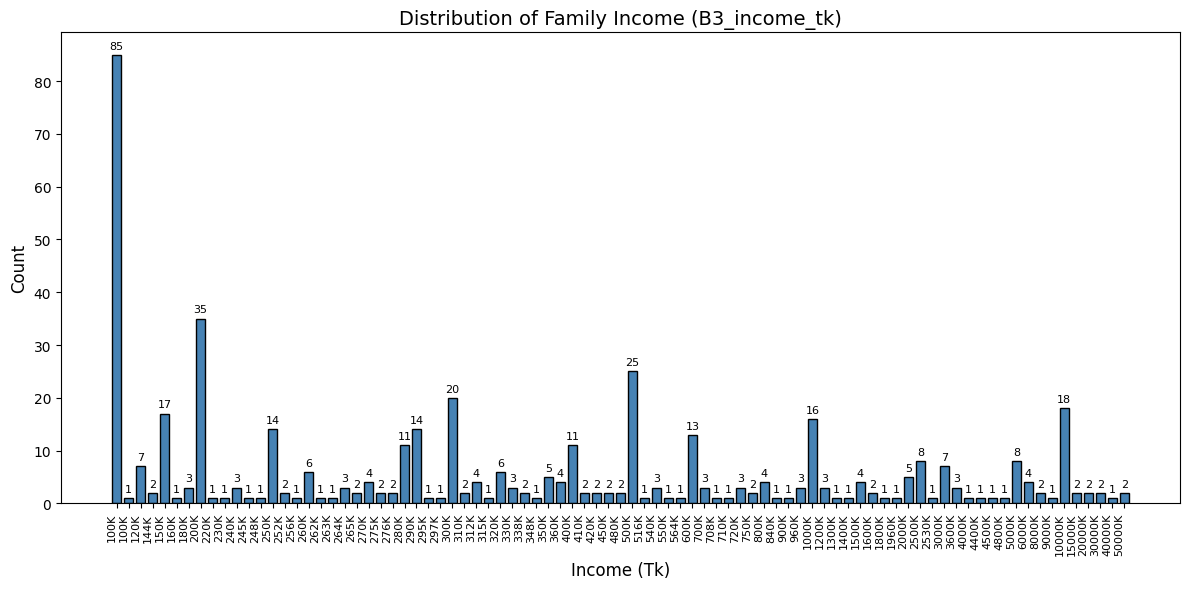

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
income_counts = df['B3_income_tk'].value_counts().sort_index()
bars = ax.bar(range(len(income_counts)), income_counts.values, color='steelblue', edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(income_counts)))
ax.set_xticklabels([f'{int(x/1000)}K' for x in income_counts.index], rotation=90, ha='right', fontsize=8)
plt.title('Distribution of Family Income (B3_income_tk)', fontsize=14)
plt.xlabel('Income (Tk)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Check B3_income_tk values
print(f"Min: {df['B3_income_tk'].min()}")
print(f"Max: {df['B3_income_tk'].max()}")
print(f"Mean: {df['B3_income_tk'].mean():.2f}")
print(f"Median: {df['B3_income_tk'].median()}")
print()
print("Value counts:")
print(df['B3_income_tk'].value_counts().sort_index())

Min: 100000
Max: 50000000
Mean: 1675413.93
Median: 300000.0

Value counts:
B3_income_tk
100000      85
100008       1
120000       7
144000       2
150000      17
            ..
15000000     2
20000000     2
30000000     2
40000000     1
50000000     2
Name: count, Length: 85, dtype: int64


In [21]:
# Income categories (3 classes)
# Low Income (≤150K)', 'Middle Income (150K-300K)', 'High Income (>300K)'
bins = [0, 150000, 300000, float('inf')]
labels = ['Low Income (≤150K)', 'Middle Income (150K-300K)', 'High Income (>300K)']
df['income_class'] = pd.cut(df['B3_income_tk'], bins=bins, labels=labels)

print(df['income_class'].value_counts())

income_class
High Income (>300K)          209
Middle Income (150K-300K)    131
Low Income (≤150K)           112
Name: count, dtype: int64


# Physical problem

In [22]:
df['C3_physical_problems'].value_counts()

C3_physical_problems
Headache                                                                                                              80
Irritable mood                                                                                                        38
Eye irritation                                                                                                        36
Headache, Irritable mood                                                                                              27
Others                                                                                                                25
                                                                                                                      ..
Loss of appetite, Irritable mood, Obesity, Sleeplessness                                                               1
Eye irritation, Headache, Joint pain / bone pain, Loss of appetite, Irritable mood, Obesity, Sleeplessness, Others     1
Headache, L

In [23]:
# Get top 15 physical problems (excluding "Others")
top_values = df['C3_physical_problems'].value_counts()
top_values = top_values[top_values.index != 'Others'].head(15).index.tolist()

# keep top values, label others as 'Other'
df['C3_physical_problems'] = df['C3_physical_problems'].apply(lambda x: x if x in top_values else 'Other')
df['C3_physical_problems'].value_counts()

C3_physical_problems
Other                                       146
Headache                                     80
Irritable mood                               38
Eye irritation                               36
Headache, Irritable mood                     27
Eye irritation, Headache                     19
Loss of appetite                             16
Headache, Irritable mood, Obesity            14
Sleeplessness                                13
Loss of appetite, Irritable mood             12
Headache, Sleeplessness                      10
Eye irritation, Headache, Irritable mood     10
Irritable mood, Obesity                      10
Obesity                                       9
Headache, Obesity                             6
Headache, Loss of appetite                    6
Name: count, dtype: int64

# digital content

In [24]:
# Get top 10 content types
top_content = df['D4_content'].value_counts().head(10).index.tolist()

# Create new column - keep top 10, label others as 'Other'
df['D4_content'] = df['D4_content'].apply(lambda x: x if x in top_content else 'Other')

df['D4_content'].value_counts()

D4_content
Other                                                                        171
Social Media                                                                  75
Videos                                                                        62
Educational Content                                                           43
Music                                                                         28
Games                                                                         24
Videos, Social Media, Educational Content                                     11
Games, Videos, Music, Social Media, Educational Content                       10
Videos, Social Media                                                          10
Games, Videos                                                                  9
Games, Videos, Music, Social Media, Video Chat, Educational Content, News      9
Name: count, dtype: int64

# bed time

In [25]:
df['E5_bedtime'].value_counts()

E5_bedtime
11:00 PM    71
12:00 AM    65
01:00 AM    50
11:30 PM    43
10:00 PM    34
10:30 PM    32
12:30 AM    24
02:00 AM    23
03:00 AM    22
01:30 AM     8
12:30 PM     5
04:00 AM     5
02:30 AM     5
01:30 PM     4
09:30 PM     4
12:40 AM     3
11:40 PM     3
09:00 PM     3
11:50 PM     3
02:30 PM     2
12:00 PM     2
02:26 AM     2
11:59 PM     2
11:01 PM     2
12:45 AM     2
11:31 PM     1
10:31 PM     1
02:10 PM     1
03:17 AM     1
11:45 PM     1
11:16 PM     1
02:07 PM     1
11:58 PM     1
10:30 AM     1
01:00 PM     1
11:29 PM     1
01:06 AM     1
12:29 AM     1
08:00 PM     1
10:43 PM     1
07:00 PM     1
08:30 PM     1
12:50 AM     1
02:32 AM     1
02:35 AM     1
01:50 AM     1
11:30 AM     1
12:31 AM     1
11:00 AM     1
12:09 AM     1
01:45 AM     1
03:33 AM     1
02:42 AM     1
12:59 AM     1
02:56 AM     1
02:40 AM     1
12:01 AM     1
12:15 AM     1
Name: count, dtype: int64

In [26]:
# Extract hour and minute from bedtime and categorize into 3 classes
def categorize_bedtime(time_str):
    try:
        time_obj = pd.to_datetime(time_str, format='%I:%M %p')
        hour = time_obj.hour
        minute = time_obj.minute
        
        # Convert to 24-hour total minutes for easier comparison
        total_minutes = hour * 60 + minute
        early_limit = 21.5 * 60  # 9:30 PM = 570 minutes
        normal_limit = 22.5 * 60  # 10:30 PM = 630 minutes
        
        if total_minutes < early_limit:  # Before 9:30 PM
            return 'Early (<9:30 PM)'
        elif early_limit <= total_minutes < normal_limit:  # 9:30 PM to 10:30 PM
            return 'Normal (9:30-10:30 PM)'
        else:  # After 10:30 PM
            return 'Late (>10:30 PM)'
    except:
        return 'Unknown'

df['E5_bedtime'] = df['E5_bedtime'].apply(categorize_bedtime)
df['E5_bedtime'].value_counts()

E5_bedtime
Early (<9:30 PM)          251
Late (>10:30 PM)          163
Normal (9:30-10:30 PM)     38
Name: count, dtype: int64

# wake up time

In [27]:
# Extract hour and minute from wake time and categorize into 3 classes
def categorize_wake_time(time_str):
    try:
        # Try multiple formats
        for fmt in ['%I:%M %p', '%H:%M']:
            try:
                time_obj = pd.to_datetime(time_str.strip(), format=fmt)
                hour = time_obj.hour
                minute = time_obj.minute
                
                # Convert to 24-hour total minutes for easier comparison
                total_minutes = hour * 60 + minute
                early_limit = 6 * 60  # 6:00 AM = 360 minutes
                normal_limit = 7 * 60  # 7:00 AM = 420 minutes
                
                if total_minutes < early_limit:  # Before 6:00 AM
                    return 'Early (<6:00 AM)'
                elif early_limit <= total_minutes < normal_limit:  # 6:00 AM to 7:00 AM
                    return 'Normal (6:00-7:00 AM)'
                else:  # After 7:00 AM
                    return 'Late (>7:00 AM)'
            except:
                continue
        return 'Unknown'
    except:
        return 'Unknown'

df['E6_wake_time'] = df['E6_wake_time'].apply(categorize_wake_time)
df['E6_wake_time'].value_counts()

E6_wake_time
Late (>7:00 AM)          256
Normal (6:00-7:00 AM)    125
Early (<6:00 AM)          71
Name: count, dtype: int64

## Simple Case Study

In [28]:
df2 = df[['PHQ_class','age_class','A2_gender','D1_daily_screen','A3_religion', 'A4_marital', 'B1_residence',
         'income_class', 'B4_family_type',
          'B5_time_with_parents_hours', 'B6_relationship_with_family','weight_class',
          'C3_physical_problems', 'D2_weekend_screen',
          'D3_device', 'D4_content', 'D5_parents_screen_time', 'D6_ai_daily',
          'D7_ai_impact', 'D8_creativity_decline', 'E1_sleep_duration','E3_sleep_medicine', 'E4_addictive_drug',
          'E5_bedtime', 'E6_wake_time', 'F1_academic_satisfaction',
          'F2_screen_impact', 'F3_learning_interest', 'F4_interest_reduced',
          'G1_mood_swings', 'G2_anxious_without_device', 'G3_communication',
          'G4_isolation', 'G5_negative_mental', 'G6_panic_attack','H1_mobile_while_eating', 'H2_appetite_change', 'BMI_class']]
df2.head(2)

,PHQ_class,age_class,A2_gender,D1_daily_screen,A3_religion,A4_marital,B1_residence,income_class,B4_family_type,B5_time_with_parents_hours,...,F4_interest_reduced,G1_mood_swings,G2_anxious_without_device,G3_communication,G4_isolation,G5_negative_mental,G6_panic_attack,H1_mobile_while_eating,H2_appetite_change,BMI_class
0,Moderate depressive,14-16 years,Female,3-5 hours,Islam,Unmarried,Urban area,High Income (>300K),Nuclear family,2-4 hours,...,Decreased moderately,Sometimes,Sometimes,Moderate,Very little time,Not sure,Sometimes,Always,Loss of appetite,Normal
1,Moderate depressive,11-13 years,Female,3-5 hours,Islam,Unmarried,Urban area,Low Income (≤150K),Nuclear family,2-4 hours,...,Decreased moderately,Often,Sometimes,Bad,Very little time,Not sure,Sometimes,Always,Loss of appetite,Underweight


In [29]:
# df2.to_csv('dataset.csv', index=False)

In [30]:
from deep_study import Analyzer
from pathlib import Path

analyzer = Analyzer(df2, target="D1_daily_screen")
report = analyzer.run()

html_path = Path("d1_daily_screen_report.html")

if hasattr(report, "_repr_html_") and callable(report._repr_html_):
    html_content = report._repr_html_()
elif isinstance(report, pd.DataFrame):
    html_content = report.to_html(index=False)
elif hasattr(report, "to_html") and callable(report.to_html):
    html_content = report.to_html()
else:
    html_content = f"<pre>{str(report)}</pre>"

if "<html" not in html_content.lower():
    html_content = f"""<!doctype html>
<html>
  <head>
    <meta charset=\"utf-8\">
    <title>D1 Daily Screen Report</title>
  </head>
  <body>
    {html_content}
  </body>
</html>"""

html_path.write_text(html_content, encoding="utf-8")
print(f"Saved HTML report to: {html_path.resolve()}")

report

Saved HTML report to: D:\thesis_analysis\d1_daily_screen_report.html


# Main Analysis

In [31]:
# from scipy.stats import chi2_contingency
# from IPython.display import display, HTML
# import matplotlib.pyplot as plt
# from matplotlib.backends.backend_pdf import PdfPages

# # Fixed margins for PDF output
# LEFT_MARGIN = 0.10
# RIGHT_MARGIN = 0.90

# def analysis(df, target, variables, section_title, save_image=True, filename="analysis_results.pdf"):
  
#     results = []
#     crosstabs = []
    
#     for i, var in enumerate(variables, 1):
#         # Cross-tabulation with margins
#         ct = pd.crosstab(df[var], df[target], margins=True, margins_name='Total')
#         crosstabs.append((var, ct))
        
#         # Display formatted table title
#         display(HTML(f"<h4>Table {i}: Cross-tabulation of {var} and {target}</h4>"))
#         display(ct.style.set_caption(f"{var} × {target}").set_table_styles([
#             {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}
#         ]))
        
#         # Chi-square test 
#         ct_test = pd.crosstab(df[var], df[target])
#         chi2, p, dof, expected = chi2_contingency(ct_test)

#         results.append({
#             'Variable': var,
#             'Chi-square value': round(chi2, 3),
#             'Degrees of freedom': dof,
#             'p-value': round(p, 4)
#         })
#         print()

#     # Display Chi-Square Summary Table
#     display(HTML(f"<h4>Table: Chi-Square Test Results for Association with {target}</h4>"))
#     chi_square_table = pd.DataFrame(results)
#     display(chi_square_table.style.set_caption("Chi-Square Test Summary").set_table_styles([
#         {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}
#     ]))
    
#     # Save all tables as A4 PDF with formal academic styling
#     if save_image:
#         plt.rcParams['font.family'] = 'Times New Roman'
#         plt.rcParams['font.size'] = 10
        
#         # A4 size in inches with margins
#         fig_width = 7.5
#         fig_height = 10.5
        
#         n_tables = len(crosstabs) + 1
        
#         # Calculate heights for each subplot
#         heights = [len(ct) + 1.5 for _, ct in crosstabs]
#         heights.append(len(results) + 1.5)
        
#         fig, axes = plt.subplots(n_tables + 1, 1, figsize=(fig_width, fig_height),
#                                  gridspec_kw={'height_ratios': [2.5] + heights})
#         fig.patch.set_facecolor('white')
        
#         # Table width based on margins
#         table_width = RIGHT_MARGIN - LEFT_MARGIN
        
#         # Header section
#         ax_header = axes[0]
#         ax_header.axis('off')
        
#         # Section title
#         ax_header.text(LEFT_MARGIN, 0.90, section_title, transform=ax_header.transAxes, 
#                       fontsize=12, fontweight='bold', fontfamily='Times New Roman', va='top')
        
#         # Target variable
#         ax_header.text(LEFT_MARGIN, 0.60, "Target Variable:", transform=ax_header.transAxes,
#                       fontsize=10, fontweight='bold', fontfamily='Times New Roman', va='top')
#         ax_header.text(LEFT_MARGIN + 0.20, 0.60, target, transform=ax_header.transAxes,
#                       fontsize=10, fontfamily='Times New Roman', va='top', style='italic')
        
#         # Variables label
#         ax_header.text(LEFT_MARGIN, 0.35, "Independent Variables:", transform=ax_header.transAxes,
#                       fontsize=10, fontweight='bold', fontfamily='Times New Roman', va='top')
        
#         # Variable list
#         var_text = ', '.join(variables)
#         ax_header.text(LEFT_MARGIN + 0.28, 0.35, var_text, transform=ax_header.transAxes,
#                       fontsize=10, fontfamily='Times New Roman', va='top', style='italic')
        
#         # Cross-tabulation tables
#         for idx, (var, ct) in enumerate(crosstabs):
#             ax = axes[idx + 1]
#             ax.axis('off')
            
#             # Table title - formal style
#             ax.text(LEFT_MARGIN, 0.98, f"Table {idx+1}.", transform=ax.transAxes, 
#                    fontsize=10, fontweight='bold', fontfamily='Times New Roman', va='top')
#             ax.text(LEFT_MARGIN + 0.08, 0.98, f"Cross-tabulation of {var} and {target}", 
#                    transform=ax.transAxes, fontsize=10, fontfamily='Times New Roman', 
#                    va='top', style='italic')
            
#             # Create table WITHOUT rowLabels - include them in cellText instead
#             row_labels = list(ct.index)
#             col_labels = [''] + list(ct.columns)  # Empty first column header
#             cell_data = []
#             for i, row_label in enumerate(row_labels):
#                 row_data = [row_label] + list(ct.values[i])
#                 cell_data.append(row_data)
            
#             table = ax.table(
#                 cellText=cell_data,
#                 colLabels=col_labels,
#                 cellLoc='center',
#                 loc='upper center',
#                 bbox=[LEFT_MARGIN, 0.0, table_width, 0.80]
#             )
#             table.auto_set_font_size(False)
#             table.set_fontsize(9)
#             table.auto_set_column_width(col=list(range(len(col_labels))))
            
#             # Set first column alignment for row labels
#             for key, cell in table.get_celld().items():
#                 row, col = key
#                 if col == 0 and row > 0:  # First column (row labels), not header
#                     cell.set_text_props(ha='left')
            
#             # Formal academic table style (horizontal lines only)
#             for (row, col), cell in table.get_celld().items():
#                 cell.set_text_props(fontfamily='Times New Roman')
#                 cell.set_facecolor('white')
#                 cell.set_edgecolor('black')
                
#                 if row == 0:  # Header row
#                     cell.set_text_props(fontweight='bold', fontfamily='Times New Roman')
#                     cell.set_linewidth(1)
#                     cell.visible_edges = 'TB'
#                 else:
#                     cell.set_linewidth(0.5)
#                     cell.visible_edges = 'B'
                
#                 # Bottom border for last row (thicker)
#                 if row == len(cell_data):
#                     cell.set_linewidth(1)
#                     cell.visible_edges = 'B'
        
#         # Chi-square summary table
#         ax = axes[-1]
#         ax.axis('off')
#         ax.text(LEFT_MARGIN, 0.98, f"Table {len(crosstabs)+1}.", transform=ax.transAxes, 
#                fontsize=10, fontweight='bold', fontfamily='Times New Roman', va='top')
#         ax.text(LEFT_MARGIN + 0.08, 0.98, f"Test Results for Association with {target}", 
#                transform=ax.transAxes, fontsize=10, fontfamily='Times New Roman', 
#                va='top', style='italic')
        
#         chi_df = chi_square_table
#         table = ax.table(
#             cellText=chi_df.values,
#             colLabels=chi_df.columns,
#             cellLoc='center',
#             loc='upper center',
#             bbox=[LEFT_MARGIN, 0.0, table_width, 0.80]
#         )
#         table.auto_set_font_size(False)
#         table.set_fontsize(10)
        
#         for (row, col), cell in table.get_celld().items():
#             cell.set_text_props(fontfamily='Times New Roman')
#             cell.set_facecolor('white')
#             cell.set_edgecolor('black')
            
#             if row == 0:
#                 cell.set_text_props(fontweight='bold', fontfamily='Times New Roman')
#                 cell.set_linewidth(1)
#                 cell.visible_edges = 'TB'
#             else:
#                 cell.set_linewidth(0.5)
#                 cell.visible_edges = 'B'
            
#             if row == len(chi_df):
#                 cell.set_linewidth(1)
#                 cell.visible_edges = 'B'
        
#         plt.subplots_adjust(top=0.96, bottom=0.04, hspace=0.25, left=0.02, right=0.98)
        
#         # Save as PDF
#         with PdfPages(filename) as pdf:
#             pdf.savefig(fig, facecolor='white', dpi=300)
#         plt.close()
        
#         plt.rcParams['font.family'] = plt.rcParamsDefault['font.family']
#         print(f"Saved: {filename}")
    
#     return chi_square_table

# target = 'D1_daily_screen'
# variables = ['age_class','A2_gender', 'A4_marital', 'B4_family_type',
#           'B5_time_with_parents_hours', 'B6_relationship_with_family',
#           'D3_device', 'D4_content', 'D5_parents_screen_time', 'E1_sleep_duration','E3_sleep_medicine', 
#           'E5_bedtime', 'E6_wake_time', 'F1_academic_satisfaction',
#           'F2_screen_impact', 'F3_learning_interest', 'F4_interest_reduced',
#          'G2_anxious_without_device', 
#           'G4_isolation', 'G6_panic_attack','H1_mobile_while_eating', 'H2_appetite_change', 'BMI_class']


# _ = analysis(df2, target, variables, section_title="Depression", filename="18.Depression.pdf")

In [32]:
# from scipy.stats import chi2_contingency
# from IPython.display import display, HTML
# import matplotlib.pyplot as plt
# from matplotlib.backends.backend_pdf import PdfPages
# import numpy as np
# from datetime import datetime

# # Fixed margins for PDF output
# LEFT_MARGIN = 0.10
# RIGHT_MARGIN = 0.90

# def analysis(df, target, variables, section_title, save_image=True, filename="analysis_results.pdf"):
  
#     results = []
#     crosstabs = []
    
#     for i, var in enumerate(variables, 1):
#         # Cross-tabulation with margins
#         ct = pd.crosstab(df[var], df[target], margins=True, margins_name='Total')
#         crosstabs.append((var, ct))
        
#         # Display formatted table title
#         display(HTML(f"""
#             <div style="margin-top: 20px; margin-bottom: 10px;">
#                 <h4 style="border-bottom: 2px solid #333; padding-bottom: 8px;">
#                     Table {i}: Cross-tabulation of {var} and {target}
#                 </h4>
#             </div>
#         """))
#         display(ct.style.set_caption(f"{var} × {target}")
#                         .set_table_styles([
#                             {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '12px')]},
#                             {'selector': 'thead', 'props': [('background-color', '#f0f0f0'), ('border', '1px solid #999')]},
#                             {'selector': 'tbody td', 'props': [('border', '1px solid #ccc'), ('padding', '8px')]},
#                             {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#fafafa')]},
#                         ])
#                         .format(precision=0)
#         )
        
#         # Chi-square test 
#         ct_test = pd.crosstab(df[var], df[target])
#         chi2, p, dof, expected = chi2_contingency(ct_test)
        
#         # Add significance indicator
#         significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

#         results.append({
#             'Variable': var,
#             'χ² Statistic': round(chi2, 3),
#             'df': dof,
#             'p-value': round(p, 4),
#             'Sig.': significance
#         })
#         print()

#     # Display Chi-Square Summary Table
#     display(HTML(f"""
#         <div style="margin-top: 30px; margin-bottom: 15px;">
#             <h4 style="border-bottom: 2px solid #333; padding-bottom: 8px;">
#                 Chi-Square Test Results Summary
#             </h4>
#         </div>
#     """))
#     chi_square_table = pd.DataFrame(results)
#     display(chi_square_table.style.set_caption("Note: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
#                         .set_table_styles([
#                             {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '10px'), ('color', '#555')]},
#                             {'selector': 'thead', 'props': [('background-color', '#e0e0e0'), ('border', '1px solid #666')]},
#                             {'selector': 'tbody td', 'props': [('border', '1px solid #ccc'), ('padding', '10px'), ('text-align', 'center')]},
#                             {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#fafafa')]},
#                         ])
#                         .format(precision=4)
#     )
    
#     # Save all tables as multi-page A4 PDF with clean professional styling
#     if save_image:
#         plt.rcParams['font.family'] = 'Calibri'
#         plt.rcParams['font.size'] = 10
        
#         # A4 size in inches
#         fig_width = 8.5
#         fig_height = 11
#         table_width = RIGHT_MARGIN - LEFT_MARGIN
        
#         # Create multi-page PDF
#         with PdfPages(filename) as pdf:
#             page_num = 1
            
#             # Page 1: Title/Header
#             fig = plt.figure(figsize=(fig_width, fig_height))
#             fig.patch.set_facecolor('white')
#             ax = fig.add_subplot(111)
#             ax.axis('off')
#             # Remove all spines
#             for spine in ax.spines.values():
#                 spine.set_visible(False)
            
#             # Section title
#             ax.text(0.5, 0.90, section_title, transform=ax.transAxes, 
#                    fontsize=16, fontweight='bold', fontfamily='Calibri', 
#                    va='top', ha='center', color='black')
            
#             # Target variable
#             ax.text(LEFT_MARGIN, 0.80, "Outcome Variable:", transform=ax.transAxes,
#                    fontsize=11, fontweight='bold', fontfamily='Calibri', va='top')
#             ax.text(LEFT_MARGIN + 0.20, 0.80, target, transform=ax.transAxes,
#                    fontsize=11, fontfamily='Calibri', va='top')
            
#             # Variables label and column
#             ax.text(LEFT_MARGIN, 0.70, "Predictor Variables:", transform=ax.transAxes,
#                    fontsize=11, fontweight='bold', fontfamily='Calibri', va='top')
            
#             # Variable list - vertical column format
#             var_display = '\n'.join(variables)
#             ax.text(LEFT_MARGIN, 0.68, var_display, transform=ax.transAxes,
#                    fontsize=9, fontfamily='Calibri', va='top')
            
            
#             # Page number
#             ax.text(0.5, 0.03, f'Page {page_num}', transform=ax.transAxes, 
#                    fontsize=9, fontfamily='Calibri', ha='center')
#             page_num += 1
            
#             pdf.savefig(fig, bbox_inches='tight', facecolor='white', dpi=300)
#             plt.close()
            
#             # Pages 2+: Individual tables
#             for var, ct in crosstabs:
#                 fig = plt.figure(figsize=(fig_width, fig_height))
#                 fig.patch.set_facecolor('white')
#                 ax = fig.add_subplot(111)
#                 ax.axis('off')
#                 # Remove all spines
#                 for spine in ax.spines.values():
#                     spine.set_visible(False)
                
#                 # Title for this table
#                 ax.text(0.5, 0.96, f"Cross-tabulation: {var} × {target}", 
#                        transform=ax.transAxes, fontsize=12, fontweight='bold', 
#                        fontfamily='Calibri', ha='center', va='top')
                
#                 # Create table data
#                 row_labels = list(ct.index)
#                 col_labels = list(ct.columns)
#                 cell_data = []
                
#                 for row_label in row_labels:
#                     row_idx = list(ct.index).index(row_label)
#                     row_data = [str(int(val)) for val in ct.values[row_idx]]
#                     cell_data.append(row_data)
                
#                 # Add row labels as first column
#                 full_data = []
#                 for i, label in enumerate(row_labels):
#                     full_data.append([str(label)] + cell_data[i])
                
#                 all_col_labels = [var] + [str(col) for col in col_labels]
                
#                 table = ax.table(
#                     cellText=full_data,
#                     colLabels=all_col_labels,
#                     cellLoc='center',
#                     loc='upper center',
#                     bbox=[0.15, 0.20, 0.70, 0.65]
#                 )
#                 table.auto_set_font_size(False)
#                 table.set_fontsize(8)
                
#                 # Styling with rotated headers (no borders)
#                 for (row, col), cell in table.get_celld().items():
#                     cell.set_text_props(fontfamily='Calibri', fontsize=9)
#                     cell.set_facecolor('white')
#                     cell.set_edgecolor('none')
#                     cell.set_linewidth(0)
                    
#                     if row == 0:  # Header row - rotate text
#                         cell.set_facecolor('#f5f5f5')
#                         cell.set_text_props(fontweight='bold', fontfamily='Calibri', fontsize=9, rotation=90)
#                         cell.set_height(0.08)  # Increase height for rotated text
                
#                 # Footer note with PHQ explanation
#                 footer_text = ("Note: Cells show frequency counts. Total is in bottom-right cell.\n"
#                               "PHQ-9 Classes: 0-4=Minimal, 5-9=Mild, 10-14=Moderate, 15-19=Moderately Severe, 20-27=Severe")
#                 ax.text(0.08, 0.05, footer_text,
#                        transform=ax.transAxes, fontsize=7, fontfamily='Calibri', 
#                        va='top', style='italic', color='#333333')
                
#                 # Page number
#                 ax.text(0.92, 0.02, f'Page {page_num}', transform=ax.transAxes, 
#                        fontsize=9, fontfamily='Calibri', ha='right')
#                 page_num += 1
                
#                 pdf.savefig(fig, bbox_inches='tight', facecolor='white', dpi=300)
#                 plt.close()
            
#             # Final page: Chi-square summary
#             fig = plt.figure(figsize=(fig_width, fig_height))
#             fig.patch.set_facecolor('white')
#             ax = fig.add_subplot(111)
#             ax.axis('off')
#             # Remove all spines
#             for spine in ax.spines.values():
#                 spine.set_visible(False)
            
#             # Title
#             ax.text(0.5, 0.96, f"Statistical Summary: Chi-Square Test Results", 
#                    transform=ax.transAxes, fontsize=12, fontweight='bold', 
#                    fontfamily='Calibri', ha='center', va='top')
            
#             chi_df = chi_square_table
#             table = ax.table(
#                 cellText=chi_df.values,
#                 colLabels=chi_df.columns,
#                 cellLoc='center',
#                 loc='upper center',
#                 bbox=[LEFT_MARGIN + 0.05, 0.20, 0.80, 0.70]
#             )
#             table.auto_set_font_size(False)
#             table.set_fontsize(8)
            
#             # Styling (no borders)
#             for (row, col), cell in table.get_celld().items():
#                 cell.set_text_props(fontfamily='Calibri', fontsize=9)
#                 cell.set_facecolor('white')
#                 cell.set_edgecolor('none')
#                 cell.set_linewidth(0)
                
#                 if row == 0:  # Header row
#                     cell.set_facecolor('#f5f5f5')
#                     cell.set_text_props(fontweight='bold', fontfamily='Calibri', fontsize=9)
            
#             # Legend
#             ax.text(0.08, 0.10, "Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant",
#                    transform=ax.transAxes, fontsize=8, fontfamily='Calibri', va='top')
            
#             # Page number
#             ax.text(0.92, 0.02, f'Page {page_num}', transform=ax.transAxes, 
#                    fontsize=9, fontfamily='Calibri', ha='right')
            
#             pdf.savefig(fig, bbox_inches='tight', facecolor='white', dpi=300)
#             plt.close()
        
#         plt.rcParams['font.family'] = plt.rcParamsDefault['font.family']
#         print(f"✓ Report saved: {filename}")
    
#     return chi_square_table

# target = 'PHQ_class'
# variables = ['age_class','A2_gender', 'A4_marital', 'B4_family_type',
#           'B5_time_with_parents_hours', 'B6_relationship_with_family',
#           'D3_device', 'D4_content', 'D5_parents_screen_time', 'E1_sleep_duration','E3_sleep_medicine', 
#           'E5_bedtime', 'E6_wake_time', 'F1_academic_satisfaction',
#           'F2_screen_impact', 'F3_learning_interest', 'F4_interest_reduced',
#          'G2_anxious_without_device', 
#           'G4_isolation', 'G6_panic_attack','H1_mobile_while_eating', 'H2_appetite_change', 'BMI_class']


# _ = analysis(df2, target, variables, section_title="Depression_Level", filename="18.Depression_Level.pdf")

# Analysis For Show

Age Group Distribution:
age_class
17-19 years    201
14-16 years    155
11-13 years     96
Name: count, dtype: int64

Age Group Percentages:
age_class
17-19 years    44.47
14-16 years    34.29
11-13 years    21.24
Name: count, dtype: float64


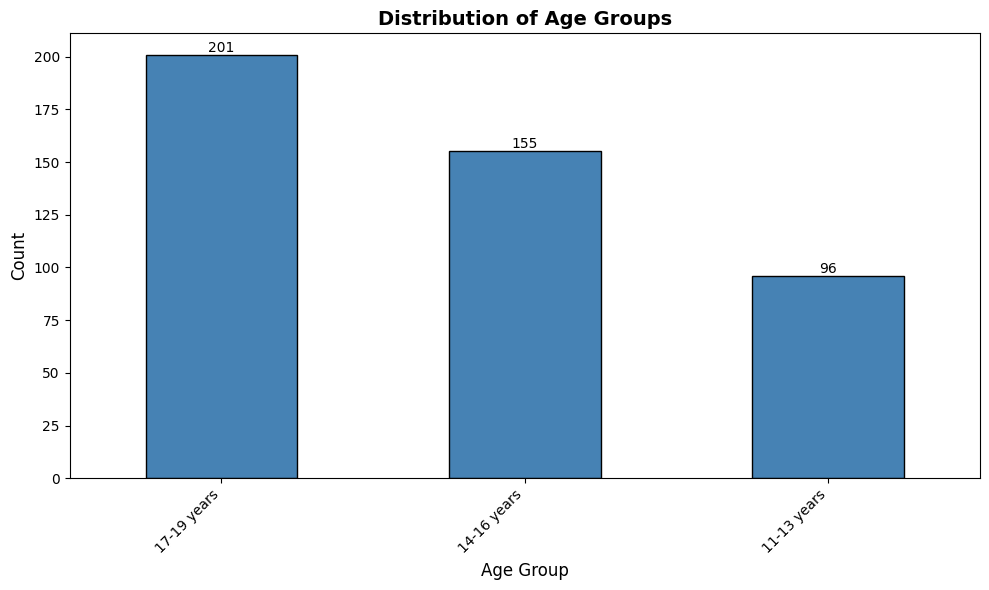

In [33]:
import matplotlib.pyplot as plt

# Display age group distribution
age_counts = df2['age_class'].value_counts()
print("Age Group Distribution:")
print(age_counts)
print("\nAge Group Percentages:")
print((age_counts / len(df2) * 100).round(2))

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
age_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Age Groups', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Gender Distribution:
A2_gender
Female    233
Male      219
Name: count, dtype: int64

Gender Percentages:
A2_gender
Female    51.55
Male      48.45
Name: count, dtype: float64


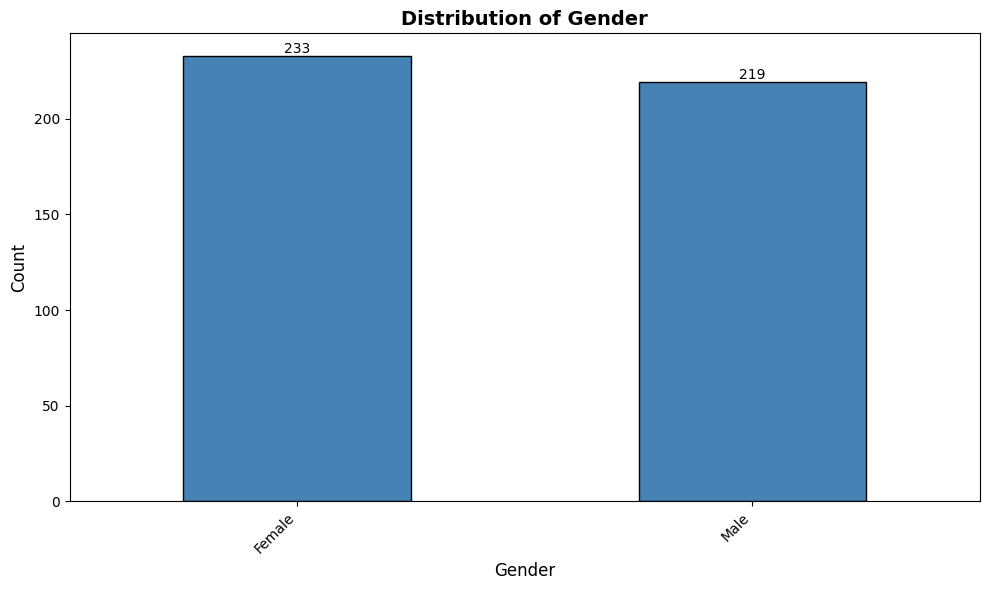

In [34]:
import matplotlib.pyplot as plt

# Display gender distribution
gender_counts = df2['A2_gender'].value_counts()
print("Gender Distribution:")
print(gender_counts)
print("\nGender Percentages:")
print((gender_counts / len(df2) * 100).round(2))

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
gender_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribution of Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

SCREENTIME BY RESIDENCE (URBAN vs RURAL)

Residence Types:
B1_residence
Urban area    242
Rural area    210
Name: count, dtype: int64

Cross-tabulation (Daily Screen Time by Residence):
D1_daily_screen  1-3 hours  3-5 hours  Less than 1 hour  More than 5 hours  \
B1_residence                                                                 
Rural area              76         42                68                 24   
Urban area              61         83                44                 54   
All                    137        125               112                 78   

D1_daily_screen  All  
B1_residence          
Rural area       210  
Urban area       242  
All              452  


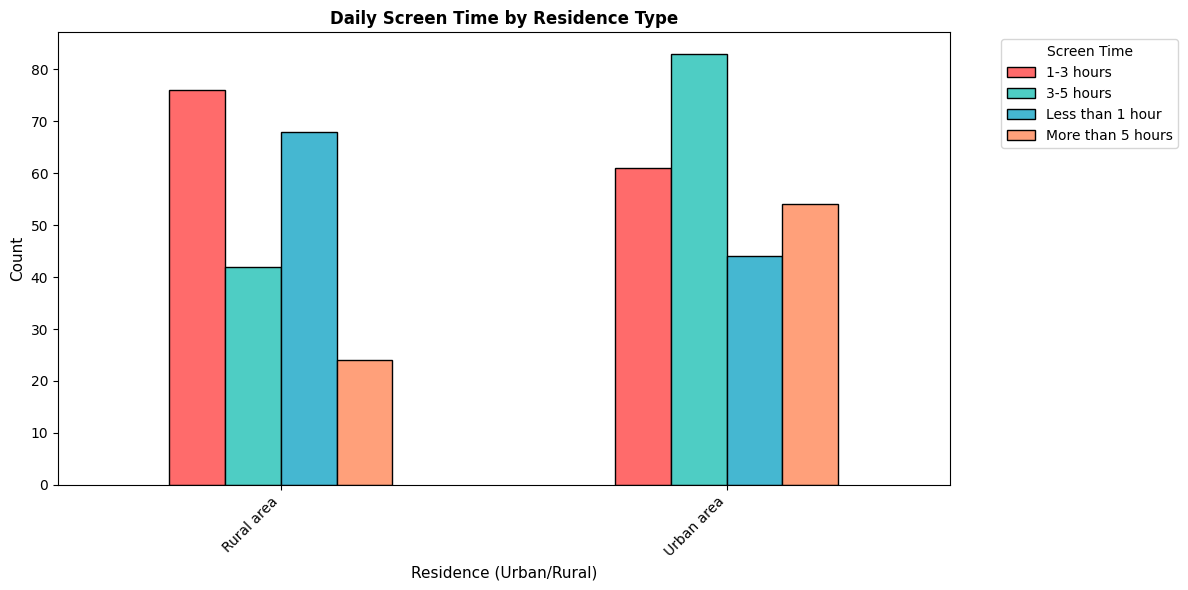


SUMMARY BY RESIDENCE TYPE

Urban area:
D1_daily_screen
3-5 hours            83
1-3 hours            61
More than 5 hours    54
Less than 1 hour     44
Name: count, dtype: int64
Total count: 242

Rural area:
D1_daily_screen
1-3 hours            76
Less than 1 hour     68
3-5 hours            42
More than 5 hours    24
Name: count, dtype: int64
Total count: 210


In [35]:
# Urban vs Rural Analysis
print("=" * 60)
print("SCREENTIME BY RESIDENCE (URBAN vs RURAL)")
print("=" * 60)

# Check the residence categories
print("\nResidence Types:")
print(df2['B1_residence'].value_counts())

# Cross-tabulation of residence and daily screen time
ct_residence = pd.crosstab(df2['B1_residence'], df2['D1_daily_screen'], margins=True)
print("\nCross-tabulation (Daily Screen Time by Residence):")
print(ct_residence)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot: Grouped bar chart with multiple colors
ct_residence_no_margins = pd.crosstab(df2['B1_residence'], df2['D1_daily_screen'])
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
ct_residence_no_margins.plot(kind='bar', ax=ax, color=colors[:len(ct_residence_no_margins.columns)], edgecolor='black')
ax.set_title('Daily Screen Time by Residence Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Residence (Urban/Rural)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(title='Screen Time', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Summary statistics by residence
print("\n" + "=" * 60)
print("SUMMARY BY RESIDENCE TYPE")
print("=" * 60)
for residence in df2['B1_residence'].unique():
    residence_data = df2[df2['B1_residence'] == residence]['D1_daily_screen'].value_counts()
    print(f"\n{residence}:")
    print(residence_data)
    print(f"Total count: {len(df2[df2['B1_residence'] == residence])}")

In [36]:
from IPython.display import display, HTML
from scipy.stats import chi2_contingency

# Depression Level by Screen Time Analysis
print("=" * 60)
print("DEPRESSION LEVEL BY SCREEN TIME")
print("=" * 60)

# Cross-tabulation of screen time and depression level
ct_depression = pd.crosstab(df2['D1_daily_screen'], df2['PHQ_class'], margins=True)

# Display as formatted HTML table
display(HTML("<h3>Table: Cross-tabulation of Daily Screen Time and Depression Level</h3>"))
display(ct_depression.style.set_caption("Depression Level by Daily Screen Time")
                           .set_table_styles([
                               {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '12px')]},
                               {'selector': 'thead', 'props': [('background-color', '#4ECDC4'), ('color', 'white'), ('font-weight', 'bold')]},
                               {'selector': 'tbody td', 'props': [('border', '1px solid #ddd'), ('padding', '10px'), ('text-align', 'center')]},
                               {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#f9f9f9')]},
                               {'selector': 'tbody tr:last-child', 'props': [('background-color', '#e8f8f7'), ('font-weight', 'bold')]},
                           ])
                           .format("{:.0f}"))

# Chi-square test for association
ct_test = pd.crosstab(df2['D1_daily_screen'], df2['PHQ_class'])
chi2, p_value, dof, expected = chi2_contingency(ct_test)

# Display Chi-square results
print("\n" + "=" * 60)
print("CHI-SQUARE TEST RESULTS")
print("=" * 60)

chi_results = pd.DataFrame({
    'Test Statistic': [f'{chi2:.4f}'],
    'P-value': [f'{p_value:.4f}'],
    'Degrees of Freedom': [dof],
    'Result': ['Significant (p < 0.05)' if p_value < 0.05 else 'Not Significant (p ≥ 0.05)']
})

display(HTML("<h3>Statistical Test Results</h3>"))
display(chi_results.style.set_table_styles([
    {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '12px')]},
    {'selector': 'thead', 'props': [('background-color', '#FF6B6B'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tbody td', 'props': [('border', '1px solid #ddd'), ('padding', '10px')]},
]))

# Summary by screen time
print("\nSummary by Screen Time:")
summary_data = []
for screen_time in sorted(df2['D1_daily_screen'].unique()):
    screen_data = df2[df2['D1_daily_screen'] == screen_time]['PHQ_class'].value_counts().sort_index()
    total = len(df2[df2['D1_daily_screen'] == screen_time])
    summary_data.append({'Screen Time': screen_time, 'Total': total})

summary_df = pd.DataFrame(summary_data)
display(HTML("<h3>Summary: Sample Size by Screen Time</h3>"))
display(summary_df.style.set_table_styles([
    {'selector': 'thead', 'props': [('background-color', '#45B7D1'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tbody td', 'props': [('border', '1px solid #ddd'), ('padding', '10px'), ('text-align', 'center')]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', '#f9f9f9')]},
]))

DEPRESSION LEVEL BY SCREEN TIME


PHQ_class,Minimal depressive,Mild depressive,Moderate depressive,Moderately depressive,Severe depressive,All
D1_daily_screen,,,,,,
1-3 hours,13,47,56,18,3,137
3-5 hours,37,40,34,11,3,125
Less than 1 hour,19,45,32,12,4,112
More than 5 hours,17,31,20,5,5,78
All,86,163,142,46,15,452



CHI-SQUARE TEST RESULTS


,Test Statistic,P-value,Degrees of Freedom,Result
0,27.3389,0.0069,12,Significant (p < 0.05)



Summary by Screen Time:


,Screen Time,Total
0,1-3 hours,137
1,3-5 hours,125
2,Less than 1 hour,112
3,More than 5 hours,78
